# VinDr-SpineXR Exploratory Data Analysis

**Slice Q10 — Dataset Understanding**  
**Project:** QStrata — medical imaging model optimization R&D  
**Dataset:** VinDr-SpineXR v1.0.0 (PhysioNet)  
**Dataset root (container):** `/datasets/vindr-spinexr`

This notebook answers:
- What is in the dataset?
- What labels exist and how are they distributed?
- What annotations and bounding boxes exist?
- What image dimensions and quality characteristics exist?
- How are ROIs distributed relative to images?
- Are there obvious data quality issues?
- Is this dataset suitable for ROI classification conversion?

**This is understanding only. No modelling decisions are made in this slice.**

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom

warnings.filterwarnings('ignore', category=UserWarning)

# Dataset root inside the container
DATASET_ROOT = '/datasets/vindr-spinexr'
TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, 'train_images')
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, 'test_images')
TRAIN_CSV     = os.path.join(DATASET_ROOT, 'annotations', 'train.csv')
TEST_CSV      = os.path.join(DATASET_ROOT, 'annotations', 'test.csv')

random.seed(42)
np.random.seed(42)

print('Dataset root:', DATASET_ROOT)
print('All required paths present:',
      all(os.path.exists(p) for p in [TRAIN_IMG_DIR, TEST_IMG_DIR, TRAIN_CSV, TEST_CSV]))
print(f'pydicom version: {pydicom.__version__}')

Dataset root: /datasets/vindr-spinexr
All required paths present: True
pydicom version: 3.0.2


---
## Section 1 — Dataset Discovery

Establish what exists on disk: file counts, directory structure, annotation file overview.

In [2]:
# File counts by type
def count_by_ext(root, ext):
    count = 0
    for dirpath, _, files in os.walk(root):
        count += sum(1 for f in files if f.endswith(ext))
    return count

print('=== File counts by type ===')
for ext in ['.dicom', '.csv', '.txt', '.pdf', '.json']:
    print(f'  {ext:10s}: {count_by_ext(DATASET_ROOT, ext):6d}')

=== File counts by type ===
  .dicom    :  10480
  .csv      :      4
  .txt      :      6
  .pdf      :      2
  .json     :      0


In [3]:
# Directory tree summary (top 3 levels)
print('=== Directory tree (top 3 levels) ===')
for dirpath, dirnames, filenames in os.walk(DATASET_ROOT):
    depth = dirpath.replace(DATASET_ROOT, '').count(os.sep)
    if depth > 2:
        dirnames[:] = []
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(dirpath)}/')
    if depth < 2:
        sub = '  ' * (depth + 1)
        for f in sorted(filenames)[:8]:
            print(f'{sub}{f}')
        if len(filenames) > 8:
            print(f'{sub}... ({len(filenames)} files total)')

=== Directory tree (top 3 levels) ===
vindr-spinexr/
  LICENSE.txt
  SHA256SUMS.txt
  supplemental_file_DICOM_tags_SpineXR.pdf
  urls_aria2.txt
  train_images/
    00073745e02e69432c002b527c565151.dicom
    00087195a35bb9948323aa89ccb2a860.dicom
    000f985efcb28afd281e3cd1b4d370ee.dicom
    0010f17b1f0257aa38426dbcea83f67d.dicom
    002b3e389ea9d92ecbf0145c2ab73625.dicom
    002c44f80a4cd39feed50e2b24327877.dicom
    002da75459bb64beb2117defd68ebcd1.dicom
    003351cd91a49e52a5a3db5ec68961ab.dicom
    ... (8389 files total)
  physionet.org/
    robots.txt
    files/
  annotations/
    test.csv
    train.csv
  _speed_test/
    annotations/
    test_images/
  test_images/
    000b3dad09378f680c845f8d7827d6ad.dicom
    000bcd6560f4551b9b74abffa5a688a0.dicom
    00175a890bdc7f1cc48ea616a64e6d6b.dicom
    001965d7ee25b931993d6b6b1adb8cc4.dicom
    003d256dd767bf8500bd7319d6792e21.dicom
    004004095d8a302b1c0815ccb044c018.dicom
    005c62dd9be402dcd71211d8eb039295.dicom
    00e30b6d3e73df2

In [4]:
# Split structure
train_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.dicom')]
test_files  = [f for f in os.listdir(TEST_IMG_DIR)  if f.endswith('.dicom')]

print('=== Split structure ===')
print(f'  Train images : {len(train_files):,}')
print(f'  Test  images : {len(test_files):,}')
print(f'  Total images : {len(train_files) + len(test_files):,}')
print(f'  Train/test split ratio: {len(train_files)/(len(train_files)+len(test_files)):.1%} / {len(test_files)/(len(train_files)+len(test_files)):.1%}')
print()
print('=== Annotation files ===')
for csv_path in [TRAIN_CSV, TEST_CSV]:
    size_kb = os.path.getsize(csv_path) / 1024
    print(f'  {os.path.basename(csv_path):12s}: {size_kb:.1f} KB')

=== Split structure ===
  Train images : 8,389
  Test  images : 2,077
  Total images : 10,466
  Train/test split ratio: 80.2% / 19.8%

=== Annotation files ===
  train.csv   : 3340.6 KB
  test.csv    : 808.7 KB


In [5]:
# Load annotation CSVs
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print('=== Train annotation — first 5 rows ===')
display(df_train.head())

print('\n=== Test annotation — first 5 rows ===')
display(df_test.head())

=== Train annotation — first 5 rows ===


,study_id,series_id,image_id,rad_id,lesion_type,xmin,ymin,xmax,ymax
0,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,712.636842,961.361404,786.587719,1011.782456
1,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,789.949123,1452.126316,880.707018,1505.908772
2,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,692.468421,655.473684,746.250877,709.256140
3,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,820.201754,1603.389474,910.959649,1670.617544
4,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,739.528070,1203.382456,820.201754,1240.357895



=== Test annotation — first 5 rows ===


,study_id,series_id,image_id,rad_id,lesion_type,xmin,ymin,xmax,ymax
0,512a61ae670020dab7eccdcc120e1ab6,1e553743cdd0ad8405ba8fb25ae30012,0abbeb49c048427b10ce66a6f50d5bd4,rad1,No finding,NaN,NaN,NaN,NaN
1,512a61ae670020dab7eccdcc120e1ab6,1e553743cdd0ad8405ba8fb25ae30012,be025b59990f7160a93d43c01b342438,rad1,No finding,NaN,NaN,NaN,NaN
2,189ca21b4bbf2573e081ca499c70f023,e9194c19dc5479c89116704e19257fd9,891b20973a05772122f8938ffe1ebef4,rad1,No finding,NaN,NaN,NaN,NaN
3,189ca21b4bbf2573e081ca499c70f023,e9194c19dc5479c89116704e19257fd9,c4ed963e96cfd445e7eb120066f63a16,rad1,No finding,NaN,NaN,NaN,NaN
4,189ca21b4bbf2573e081ca499c70f023,e9194c19dc5479c89116704e19257fd9,dc78ab93eb762af33951a2b314473666,rad1,No finding,NaN,NaN,NaN,NaN


In [6]:
# Column names and dtypes
print('=== Train CSV schema ===')
print(df_train.dtypes)
print(f'\nShape: {df_train.shape}')
print(f'Unique images: {df_train["image_id"].nunique()}')
print(f'Unique studies: {df_train["study_id"].nunique()}')
print(f'Unique radiologists: {sorted(df_train["rad_id"].unique())}')

print('\n=== Test CSV schema ===')
print(df_test.dtypes)
print(f'\nShape: {df_test.shape}')
print(f'Unique images: {df_test["image_id"].nunique()}')

=== Train CSV schema ===
study_id        object
series_id       object
image_id        object
rad_id          object
lesion_type     object
xmin           float64
ymin           float64
xmax           float64
ymax           float64
dtype: object

Shape: (19550, 9)
Unique images: 8389
Unique studies: 4000
Unique radiologists: ['rad1', 'rad2', 'rad3']

=== Test CSV schema ===
study_id        object
series_id       object
image_id        object
rad_id          object
lesion_type     object
xmin           float64
ymin           float64
xmax           float64
ymax           float64
dtype: object

Shape: (4748, 9)
Unique images: 2077


---
## Section 2 — Label Exploration

Understand the label schema and class distribution.

In [7]:
# All unique label names
all_labels = sorted(df_train['lesion_type'].unique())
print(f'Unique lesion types ({len(all_labels)}):')  
for l in all_labels:
    print(f'  {l}')

Unique lesion types (8):
  Disc space narrowing
  Foraminal stenosis
  No finding
  Osteophytes
  Other lesions
  Spondylolysthesis
  Surgical implant
  Vertebral collapse


In [8]:
# Label frequencies — annotation-level (rows) and image-level
print('=== Train: annotation-level label counts ===')
train_label_counts = df_train['lesion_type'].value_counts()
print(train_label_counts)

print('\n=== Train: image-level unique images per class ===')
# Each image-id can appear multiple times (multiple rads, multiple bboxes)
img_per_label = df_train.groupby('lesion_type')['image_id'].nunique().sort_values(ascending=False)
print(img_per_label)

=== Train: annotation-level label counts ===
lesion_type
Osteophytes             12556
No finding               4260
Disc space narrowing      924
Other lesions             446
Surgical implant          429
Foraminal stenosis        387
Spondylolysthesis         280
Vertebral collapse        268
Name: count, dtype: int64

=== Train: image-level unique images per class ===
lesion_type
No finding              4260
Osteophytes             3575
Disc space narrowing     602
Other lesions            333
Foraminal stenosis       271
Spondylolysthesis        257
Surgical implant         257
Vertebral collapse       157
Name: image_id, dtype: int64


In [9]:
# Class distribution percentage (annotation-level)
pct = (train_label_counts / train_label_counts.sum() * 100).round(2)
print('=== Class distribution (%) ===')
for label, p in pct.items():
    print(f'  {label:<30s}: {p:5.2f}%')

=== Class distribution (%) ===
  Osteophytes                   : 64.23%
  No finding                    : 21.79%
  Disc space narrowing          :  4.73%
  Other lesions                 :  2.28%
  Surgical implant              :  2.19%
  Foraminal stenosis            :  1.98%
  Spondylolysthesis             :  1.43%
  Vertebral collapse            :  1.37%


In [10]:
# Multi-label analysis: number of distinct lesion types per image
# Use one rad to avoid double-counting; rad1 appears in all
df_r1 = df_train[df_train['rad_id'] == 'rad1'].copy()
labels_per_img = df_r1.groupby('image_id')['lesion_type'].apply(
    lambda x: x[x != 'No finding'].nunique()
)
multi_label_dist = labels_per_img.value_counts().sort_index()
print('=== Distinct pathology labels per image (rad1, train) ===')
print(multi_label_dist)
print(f'\nImages with 0 pathologies (normal):  {(labels_per_img == 0).sum():,}')
print(f'Images with 1 pathology type:        {(labels_per_img == 1).sum():,}')
print(f'Images with 2+ pathology types:      {(labels_per_img >= 2).sum():,}')

=== Distinct pathology labels per image (rad1, train) ===
lesion_type
0    2308
1    1382
2     198
3      52
4      14
5       4
6       1
Name: count, dtype: int64

Images with 0 pathologies (normal):  2,308
Images with 1 pathology type:        1,382
Images with 2+ pathology types:      269


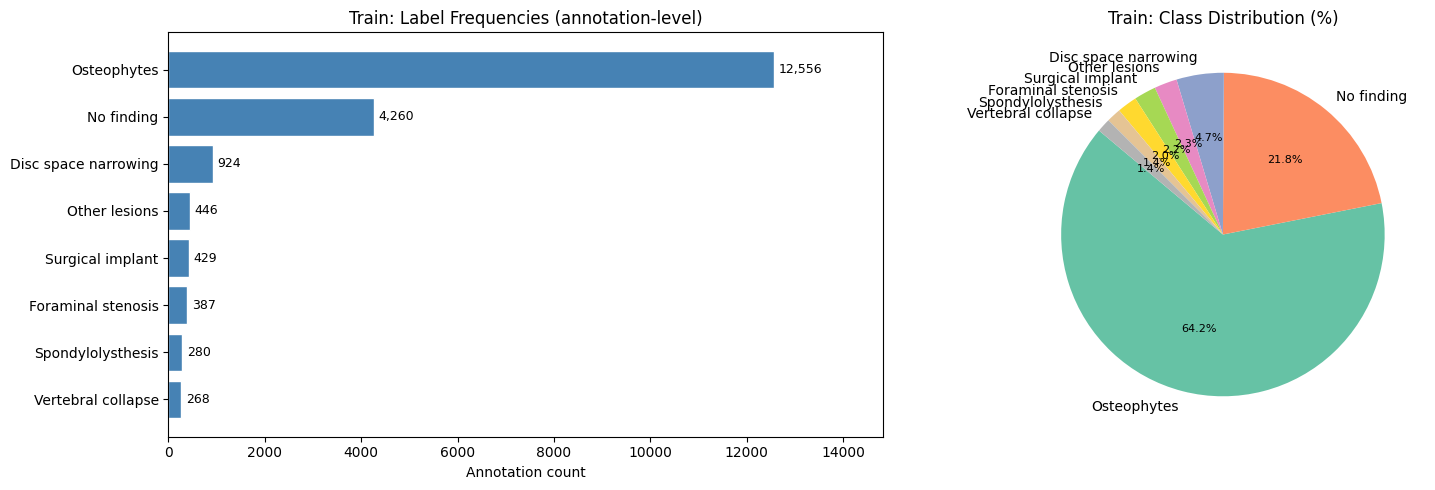

In [11]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: annotation-level label frequencies
ax = axes[0]
bars = ax.barh(train_label_counts.index[::-1], train_label_counts.values[::-1],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Annotation count')
ax.set_title('Train: Label Frequencies (annotation-level)')
for bar, val in zip(bars, train_label_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlim(0, train_label_counts.max() * 1.18)

# Pie chart: class distribution %
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    train_label_counts.values,
    labels=train_label_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors[:len(train_label_counts)]
)
for t in autotexts:
    t.set_fontsize(8)
ax2.set_title('Train: Class Distribution (%)')

plt.tight_layout()
plt.show()

---
## Section 3 — Bounding Box / ROI Exploration

Understand spatial annotation characteristics.

In [12]:
# Isolate rows with actual bounding boxes (exclude 'No finding' which have NaN coords)
df_bbox = df_train.dropna(subset=['xmin', 'ymin', 'xmax', 'ymax']).copy()
df_bbox['width']  = df_bbox['xmax'] - df_bbox['xmin']
df_bbox['height'] = df_bbox['ymax'] - df_bbox['ymin']
df_bbox['area']   = df_bbox['width'] * df_bbox['height']

print(f'Total bbox annotations (train, all rads): {len(df_bbox):,}')
print(f'Unique images with at least one bbox:     {df_bbox["image_id"].nunique():,}')

# Bboxes per image
bboxes_per_img = df_bbox.groupby('image_id').size()
print(f'\nBboxes per image:')
print(f'  mean={bboxes_per_img.mean():.2f}  std={bboxes_per_img.std():.2f}  '
      f'min={bboxes_per_img.min()}  max={bboxes_per_img.max()}')

Total bbox annotations (train, all rads): 15,290
Unique images with at least one bbox:     4,129

Bboxes per image:
  mean=3.70  std=2.63  min=1  max=21


In [13]:
# Bbox dimension statistics
for col, label in [('width', 'Bbox Width'), ('height', 'Bbox Height'), ('area', 'Bbox Area')]:
    s = df_bbox[col]
    print(f'{label}:')
    print(f'  mean={s.mean():.1f}  std={s.std():.1f}  '
          f'min={s.min():.1f}  max={s.max():.1f}')
    print(f'  p10={s.quantile(0.10):.1f}  p25={s.quantile(0.25):.1f}  '
          f'p50={s.quantile(0.50):.1f}  p75={s.quantile(0.75):.1f}  '
          f'p90={s.quantile(0.90):.1f}')
    print()

Bbox Width:
  mean=111.6  std=110.0  min=3.4  max=2027.1
  p10=42.9  p25=57.3  p50=79.2  p75=110.5  p90=202.7

Bbox Height:
  mean=126.2  std=153.3  min=3.4  max=2977.5
  p10=48.0  p25=63.1  p50=89.3  p75=147.5  p90=203.7

Bbox Area:
  mean=25879.0  std=111605.8  min=11.7  max=5372016.0
  p10=2235.0  p25=3842.0  p50=7165.8  p75=15639.0  p90=34263.3



In [14]:
# ROI area as percentage of image area
# We'll use sampled image dimensions from metadata for a representative estimate.
# Load a sample of DICOMs to get (rows, cols) and merge.
SAMPLE_N = 200
sample_ids = df_bbox['image_id'].unique()
sample_ids = np.random.choice(sample_ids, size=min(SAMPLE_N, len(sample_ids)), replace=False)

img_dims = {}
for img_id in sample_ids:
    fname = img_id + '.dicom'
    fpath = os.path.join(TRAIN_IMG_DIR, fname)
    if os.path.exists(fpath):
        try:
            ds = pydicom.dcmread(fpath, stop_before_pixels=True)
            img_dims[img_id] = (ds.Rows, ds.Columns)
        except Exception:
            pass

print(f'Sampled DICOM metadata for {len(img_dims)} images')

# Merge dimensions and compute ROI %
df_sample_bbox = df_bbox[df_bbox['image_id'].isin(img_dims)].copy()
df_sample_bbox['img_rows'] = df_sample_bbox['image_id'].map(lambda x: img_dims.get(x, (None, None))[0])
df_sample_bbox['img_cols'] = df_sample_bbox['image_id'].map(lambda x: img_dims.get(x, (None, None))[1])
df_sample_bbox = df_sample_bbox.dropna(subset=['img_rows', 'img_cols'])
df_sample_bbox['img_area'] = df_sample_bbox['img_rows'] * df_sample_bbox['img_cols']
df_sample_bbox['roi_pct']  = df_sample_bbox['area'] / df_sample_bbox['img_area'] * 100

print(f'\nROI area as % of full image area (sample n={len(df_sample_bbox)}):')
s = df_sample_bbox['roi_pct']
print(f'  mean={s.mean():.2f}%  std={s.std():.2f}%  '
      f'min={s.min():.4f}%  max={s.max():.2f}%')
print(f'  p25={s.quantile(0.25):.2f}%  median={s.median():.2f}%  p75={s.quantile(0.75):.2f}%')

Sampled DICOM metadata for 200 images

ROI area as % of full image area (sample n=703):
  mean=0.59%  std=2.69%  min=0.0104%  max=57.85%
  p25=0.09%  median=0.17%  p75=0.37%


In [15]:
# Per-label ROI size distributions
print('=== Mean bbox area by lesion_type ===')
per_label_area = df_bbox.groupby('lesion_type')['area'].agg(['mean','std','count'])
per_label_area.columns = ['mean_area', 'std_area', 'count']
per_label_area = per_label_area.sort_values('mean_area', ascending=False)
display(per_label_area.round(1))

=== Mean bbox area by lesion_type ===


,mean_area,std_area,count
lesion_type,,,
Other lesions,253744.2,517104.4,446
Surgical implant,207649.5,243805.2,429
Spondylolysthesis,86964.5,48216.3,280
Vertebral collapse,76599.3,36540.8,268
Disc space narrowing,36948.6,35846.4,924
Foraminal stenosis,9745.3,16433.1,387
Osteophytes,8812.4,7845.3,12556


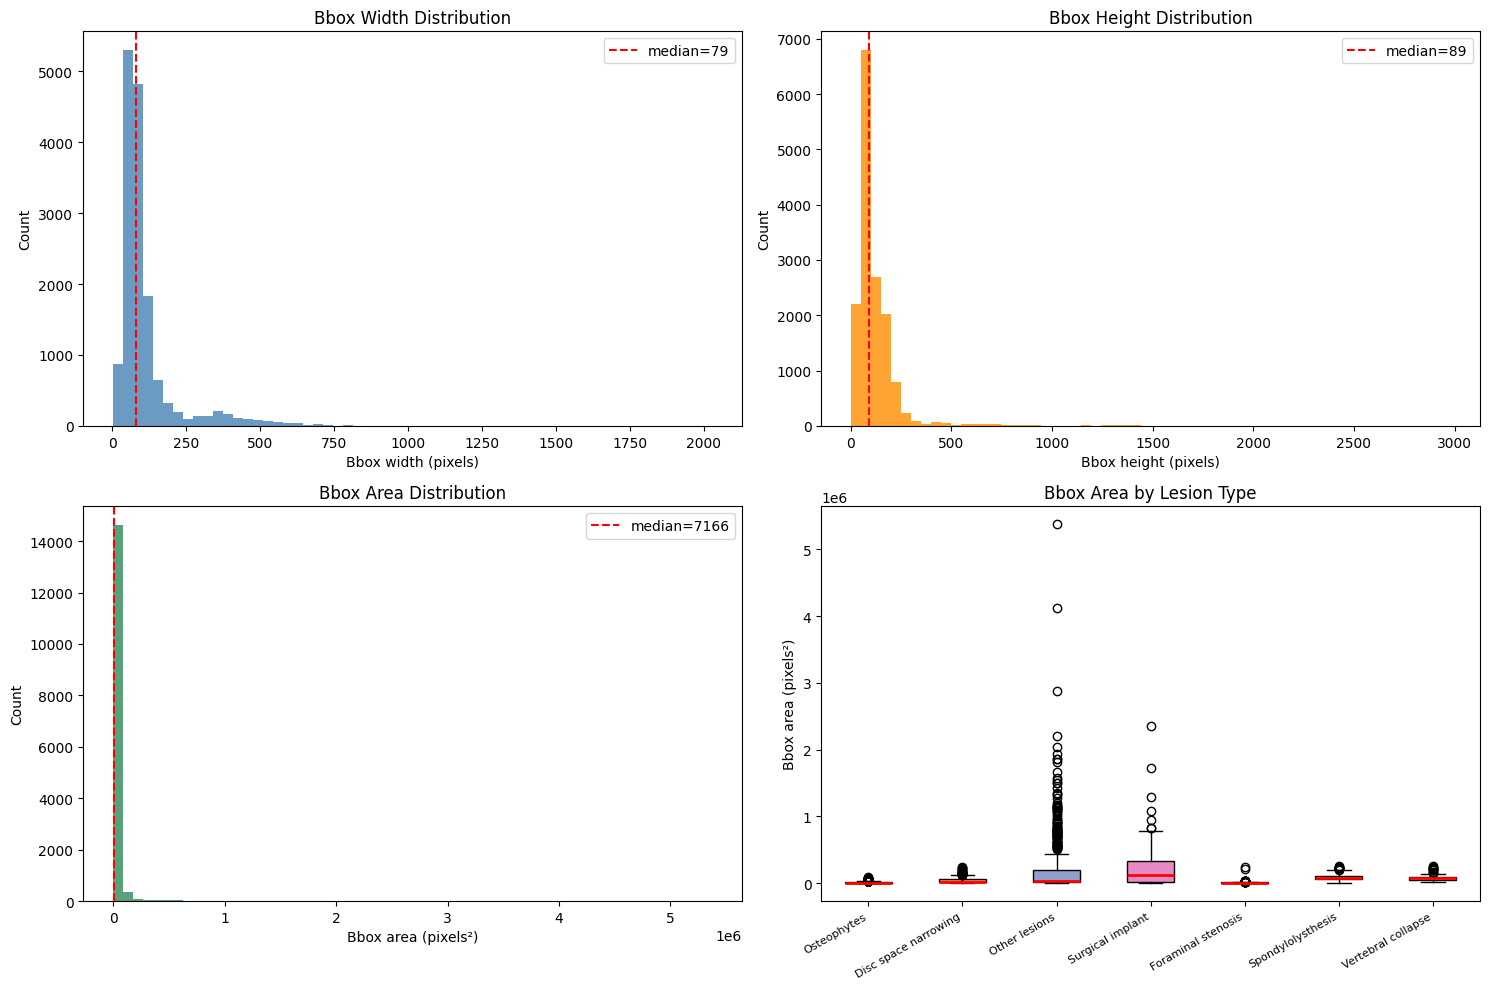

In [16]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram: bbox widths
ax = axes[0, 0]
ax.hist(df_bbox['width'], bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(df_bbox['width'].median(), color='red', linestyle='--', label=f'median={df_bbox["width"].median():.0f}')
ax.set_xlabel('Bbox width (pixels)')
ax.set_ylabel('Count')
ax.set_title('Bbox Width Distribution')
ax.legend()

# Histogram: bbox heights
ax = axes[0, 1]
ax.hist(df_bbox['height'], bins=60, color='darkorange', edgecolor='none', alpha=0.8)
ax.axvline(df_bbox['height'].median(), color='red', linestyle='--', label=f'median={df_bbox["height"].median():.0f}')
ax.set_xlabel('Bbox height (pixels)')
ax.set_ylabel('Count')
ax.set_title('Bbox Height Distribution')
ax.legend()

# Histogram: bbox areas (log scale for readability)
ax = axes[1, 0]
ax.hist(df_bbox['area'], bins=60, color='seagreen', edgecolor='none', alpha=0.8)
ax.set_xlabel('Bbox area (pixels²)')
ax.set_ylabel('Count')
ax.set_title('Bbox Area Distribution')
ax.axvline(df_bbox['area'].median(), color='red', linestyle='--', label=f'median={df_bbox["area"].median():.0f}')
ax.legend()

# Boxplot: bbox area by lesion_type
ax = axes[1, 1]
pathology_labels = [l for l in train_label_counts.index if l != 'No finding']
box_data = [df_bbox[df_bbox['lesion_type'] == l]['area'].values for l in pathology_labels]
bp = ax.boxplot(box_data, vert=True, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
colors = plt.cm.Set2.colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xticks(range(1, len(pathology_labels) + 1))
ax.set_xticklabels(pathology_labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Bbox area (pixels²)')
ax.set_title('Bbox Area by Lesion Type')

plt.tight_layout()
plt.show()

---
## Section 4 — Image Statistics

Understand image dimensions and pixel-level characteristics.

In [17]:
# Sample representative subset of train images for statistics
STAT_SAMPLE = 300
all_train_ids = [f.replace('.dicom', '') for f in train_files]
stat_ids = random.sample(all_train_ids, min(STAT_SAMPLE, len(all_train_ids)))

img_stats = []   # rows, cols, mean_px, std_px, min_px, max_px
corrupted = []

for img_id in stat_ids:
    fpath = os.path.join(TRAIN_IMG_DIR, img_id + '.dicom')
    try:
        ds  = pydicom.dcmread(fpath)
        arr = ds.pixel_array.astype(np.float32)
        img_stats.append({
            'image_id': img_id,
            'rows':     ds.Rows,
            'cols':     ds.Columns,
            'aspect':   ds.Rows / ds.Columns,
            'mean_px':  arr.mean(),
            'std_px':   arr.std(),
            'min_px':   arr.min(),
            'max_px':   arr.max(),
        })
    except Exception as e:
        corrupted.append((img_id, str(e)))

df_stats = pd.DataFrame(img_stats)
print(f'Successfully read: {len(df_stats)} / {len(stat_ids)} sampled images')
print(f'Corrupted/unreadable: {len(corrupted)}')
if corrupted:
    for cid, err in corrupted[:5]:
        print(f'  {cid}: {err}')

Successfully read: 300 / 300 sampled images
Corrupted/unreadable: 0


In [18]:
# Image dimension statistics
print('=== Image dimension statistics (sample n={}) ==='.format(len(df_stats)))
for col, label in [('rows', 'Height (rows)'), ('cols', 'Width (cols)'), ('aspect', 'Aspect ratio H/W')]:
    s = df_stats[col]
    print(f'{label}:')
    print(f'  mean={s.mean():.1f}  std={s.std():.1f}  '
          f'min={s.min():.1f}  max={s.max():.1f}')
    print(f'  p25={s.quantile(0.25):.1f}  median={s.median():.1f}  p75={s.quantile(0.75):.1f}')
    print()

print('=== Pixel intensity statistics (float32, uint16 raw values) ===')
for col, label in [('mean_px', 'Per-image mean'), ('std_px', 'Per-image std')]:
    s = df_stats[col]
    print(f'{label}: mean={s.mean():.1f}  std={s.std():.1f}  min={s.min():.1f}  max={s.max():.1f}')

=== Image dimension statistics (sample n=300) ===
Height (rows):
  mean=2405.8  std=711.5  min=1096.0  max=4144.0
  p25=1556.0  median=2874.0  p75=3028.0

Width (cols):
  mean=1612.4  std=709.0  min=675.0  max=3935.0
  p25=1164.0  median=1243.0  p75=2517.0

Aspect ratio H/W:
  mean=1.6  std=0.5  min=0.9  max=3.1
  p25=1.2  median=1.4  p75=2.2

=== Pixel intensity statistics (float32, uint16 raw values) ===
Per-image mean: mean=3917.9  std=7673.7  min=563.8  max=38787.4
Per-image std: mean=1994.9  std=3607.8  min=252.6  max=18109.0


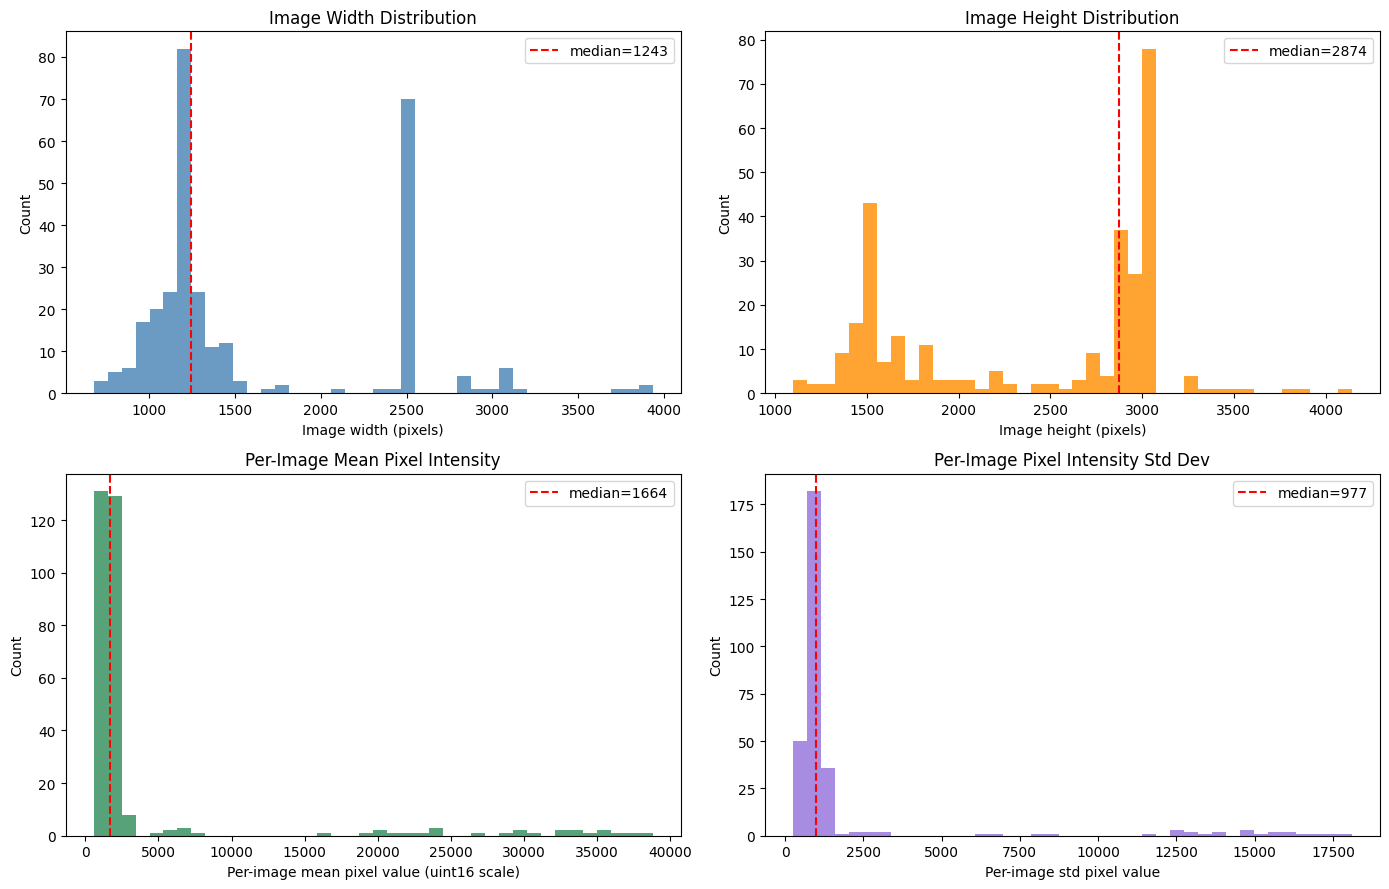

In [19]:
# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.hist(df_stats['cols'], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(df_stats['cols'].median(), color='red', linestyle='--',
           label=f'median={df_stats["cols"].median():.0f}')
ax.set_xlabel('Image width (pixels)')
ax.set_ylabel('Count')
ax.set_title('Image Width Distribution')
ax.legend()

ax = axes[0, 1]
ax.hist(df_stats['rows'], bins=40, color='darkorange', edgecolor='none', alpha=0.8)
ax.axvline(df_stats['rows'].median(), color='red', linestyle='--',
           label=f'median={df_stats["rows"].median():.0f}')
ax.set_xlabel('Image height (pixels)')
ax.set_ylabel('Count')
ax.set_title('Image Height Distribution')
ax.legend()

ax = axes[1, 0]
ax.hist(df_stats['mean_px'], bins=40, color='seagreen', edgecolor='none', alpha=0.8)
ax.set_xlabel('Per-image mean pixel value (uint16 scale)')
ax.set_ylabel('Count')
ax.set_title('Per-Image Mean Pixel Intensity')
ax.axvline(df_stats['mean_px'].median(), color='red', linestyle='--',
           label=f'median={df_stats["mean_px"].median():.0f}')
ax.legend()

ax = axes[1, 1]
ax.hist(df_stats['std_px'], bins=40, color='mediumpurple', edgecolor='none', alpha=0.8)
ax.set_xlabel('Per-image std pixel value')
ax.set_ylabel('Count')
ax.set_title('Per-Image Pixel Intensity Std Dev')
ax.axvline(df_stats['std_px'].median(), color='red', linestyle='--',
           label=f'median={df_stats["std_px"].median():.0f}')
ax.legend()

plt.tight_layout()
plt.show()

---
## Section 5 — Sample Visualization

Display sample images with bounding box overlays to visually confirm dataset contents.

In [20]:
def load_dicom_normalized(img_id, split='train'):
    """Load a DICOM image and return a float32 array normalized to [0, 1]."""
    img_dir = TRAIN_IMG_DIR if split == 'train' else TEST_IMG_DIR
    fpath = os.path.join(img_dir, img_id + '.dicom')
    ds  = pydicom.dcmread(fpath)
    arr = ds.pixel_array.astype(np.float32)
    # Normalize to [0, 1] using 2nd–98th percentile for display robustness
    p2, p98 = np.percentile(arr, [2, 98])
    arr = np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)
    return arr

def get_bboxes_for_image(image_id, df, rad='rad1'):
    """Return list of (lesion_type, xmin, ymin, xmax, ymax) for one image and rad."""
    rows = df[(df['image_id'] == image_id) & (df['rad_id'] == rad)]
    result = []
    for _, r in rows.iterrows():
        if pd.notna(r['xmin']):
            result.append((r['lesion_type'], r['xmin'], r['ymin'], r['xmax'], r['ymax']))
    return result

# Select representative examples:
# - 2 normal (No finding), plus one each of 4 pathology classes
COLORS = {
    'Osteophytes':           'cyan',
    'Disc space narrowing':  'lime',
    'Foraminal stenosis':    'yellow',
    'Spondylolysthesis':     'magenta',
    'Vertebral collapse':    'red',
    'Surgical implant':      'orange',
    'Other lesions':         'white',
    'No finding':            'blue',
}

# Gather sample image IDs
normal_imgs = df_train[(df_train['lesion_type'] == 'No finding') & (df_train['rad_id'] == 'rad1')]['image_id'].unique()

def first_img_with_label(label, df, rad='rad1'):
    ids = df[(df['lesion_type'] == label) & (df['rad_id'] == rad)]['image_id'].unique()
    for img_id in ids:
        fpath = os.path.join(TRAIN_IMG_DIR, img_id + '.dicom')
        if os.path.exists(fpath):
            return img_id
    return None

sample_ids_viz = []
# Two normal examples
for img_id in normal_imgs[:2]:
    if os.path.exists(os.path.join(TRAIN_IMG_DIR, img_id + '.dicom')):
        sample_ids_viz.append(img_id)
    if len(sample_ids_viz) >= 2:
        break

# One each of 4 pathology classes
for label in ['Osteophytes', 'Disc space narrowing', 'Vertebral collapse', 'Spondylolysthesis']:
    img_id = first_img_with_label(label, df_train)
    if img_id:
        sample_ids_viz.append(img_id)

print(f'Displaying {len(sample_ids_viz)} sample images')

Displaying 6 sample images


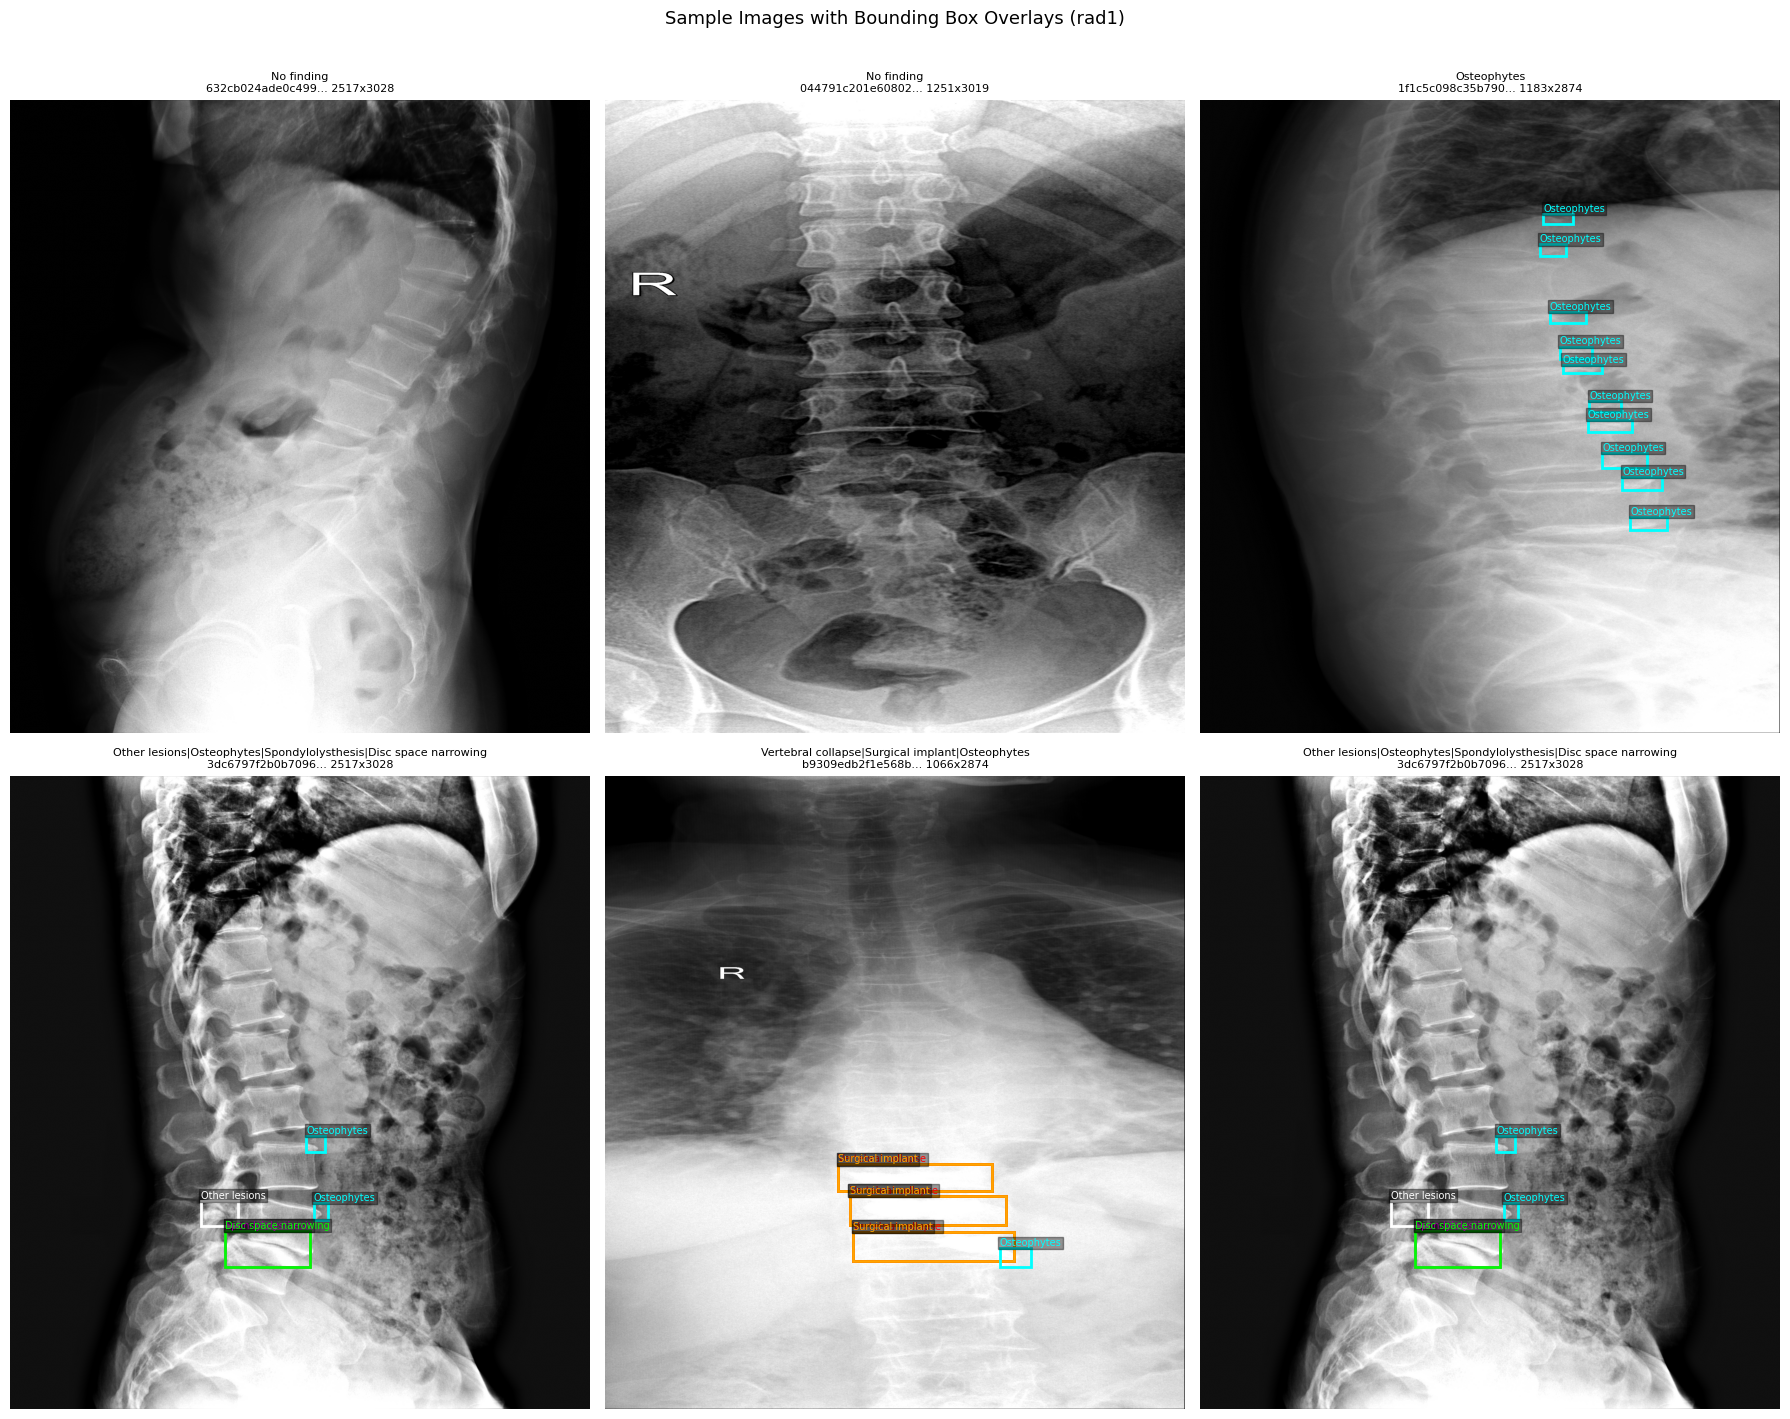

In [21]:
ncols = 3
nrows = (len(sample_ids_viz) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 7))
axes = axes.flatten()

for idx, img_id in enumerate(sample_ids_viz):
    ax = axes[idx]
    try:
        arr = load_dicom_normalized(img_id)
        bboxes = get_bboxes_for_image(img_id, df_train)

        ax.imshow(arr, cmap='gray', aspect='auto')

        label_names = []
        for (lesion, x1, y1, x2, y2) in bboxes:
            color = COLORS.get(lesion, 'white')
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 10, lesion, color=color, fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))
            if lesion not in label_names:
                label_names.append(lesion)

        if not label_names:
            label_names = ['No finding']

        ax.set_title(f'{"|".join(label_names)}\n{img_id[:16]}... {arr.shape[1]}x{arr.shape[0]}',
                     fontsize=8)
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', transform=ax.transAxes)
        ax.axis('off')

# Hide unused axes
for idx in range(len(sample_ids_viz), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Images with Bounding Box Overlays (rad1)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 6 — ROI Sanity

Assess whether ROI classification from bounding boxes is feasible by comparing full image, tight crop, and padded crop.

In [22]:
def crop_roi(arr, x1, y1, x2, y2, pad_frac=0.0):
    """Crop a bounding box from arr, with optional percentage padding."""
    h, w = arr.shape
    bw = x2 - x1
    bh = y2 - y1
    pad_x = int(bw * pad_frac)
    pad_y = int(bh * pad_frac)
    x1c = max(0, int(x1) - pad_x)
    y1c = max(0, int(y1) - pad_y)
    x2c = min(w, int(x2) + pad_x)
    y2c = min(h, int(y2) + pad_y)
    return arr[y1c:y2c, x1c:x2c]

# Select 4-6 representative examples with bboxes — one per class
ROI_LABELS = ['Osteophytes', 'Disc space narrowing', 'Vertebral collapse',
              'Foraminal stenosis', 'Surgical implant', 'Spondylolysthesis']

roi_examples = []
for label in ROI_LABELS:
    rows = df_train[(df_train['lesion_type'] == label) & (df_train['rad_id'] == 'rad1') &
                    df_train['xmin'].notna()]
    for _, row in rows.iterrows():
        fpath = os.path.join(TRAIN_IMG_DIR, row['image_id'] + '.dicom')
        if os.path.exists(fpath):
            roi_examples.append({
                'image_id': row['image_id'],
                'lesion_type': label,
                'x1': row['xmin'], 'y1': row['ymin'],
                'x2': row['xmax'], 'y2': row['ymax'],
            })
            break

print(f'ROI sanity examples: {len(roi_examples)} (one per class)')
for ex in roi_examples:
    bw = ex['x2'] - ex['x1']
    bh = ex['y2'] - ex['y1']
    print(f"  {ex['lesion_type']:<30s}: bbox {bw:.0f}x{bh:.0f} px  (area {bw*bh:.0f} px²)")

ROI sanity examples: 6 (one per class)
  Osteophytes                   : bbox 74x50 px  (area 3729 px²)
  Disc space narrowing          : bbox 369x174 px  (area 64189 px²)
  Vertebral collapse            : bbox 283x120 px  (area 33867 px²)
  Foraminal stenosis            : bbox 150x126 px  (area 18907 px²)
  Surgical implant              : bbox 215x726 px  (area 156198 px²)
  Spondylolysthesis             : bbox 369x174 px  (area 64189 px²)


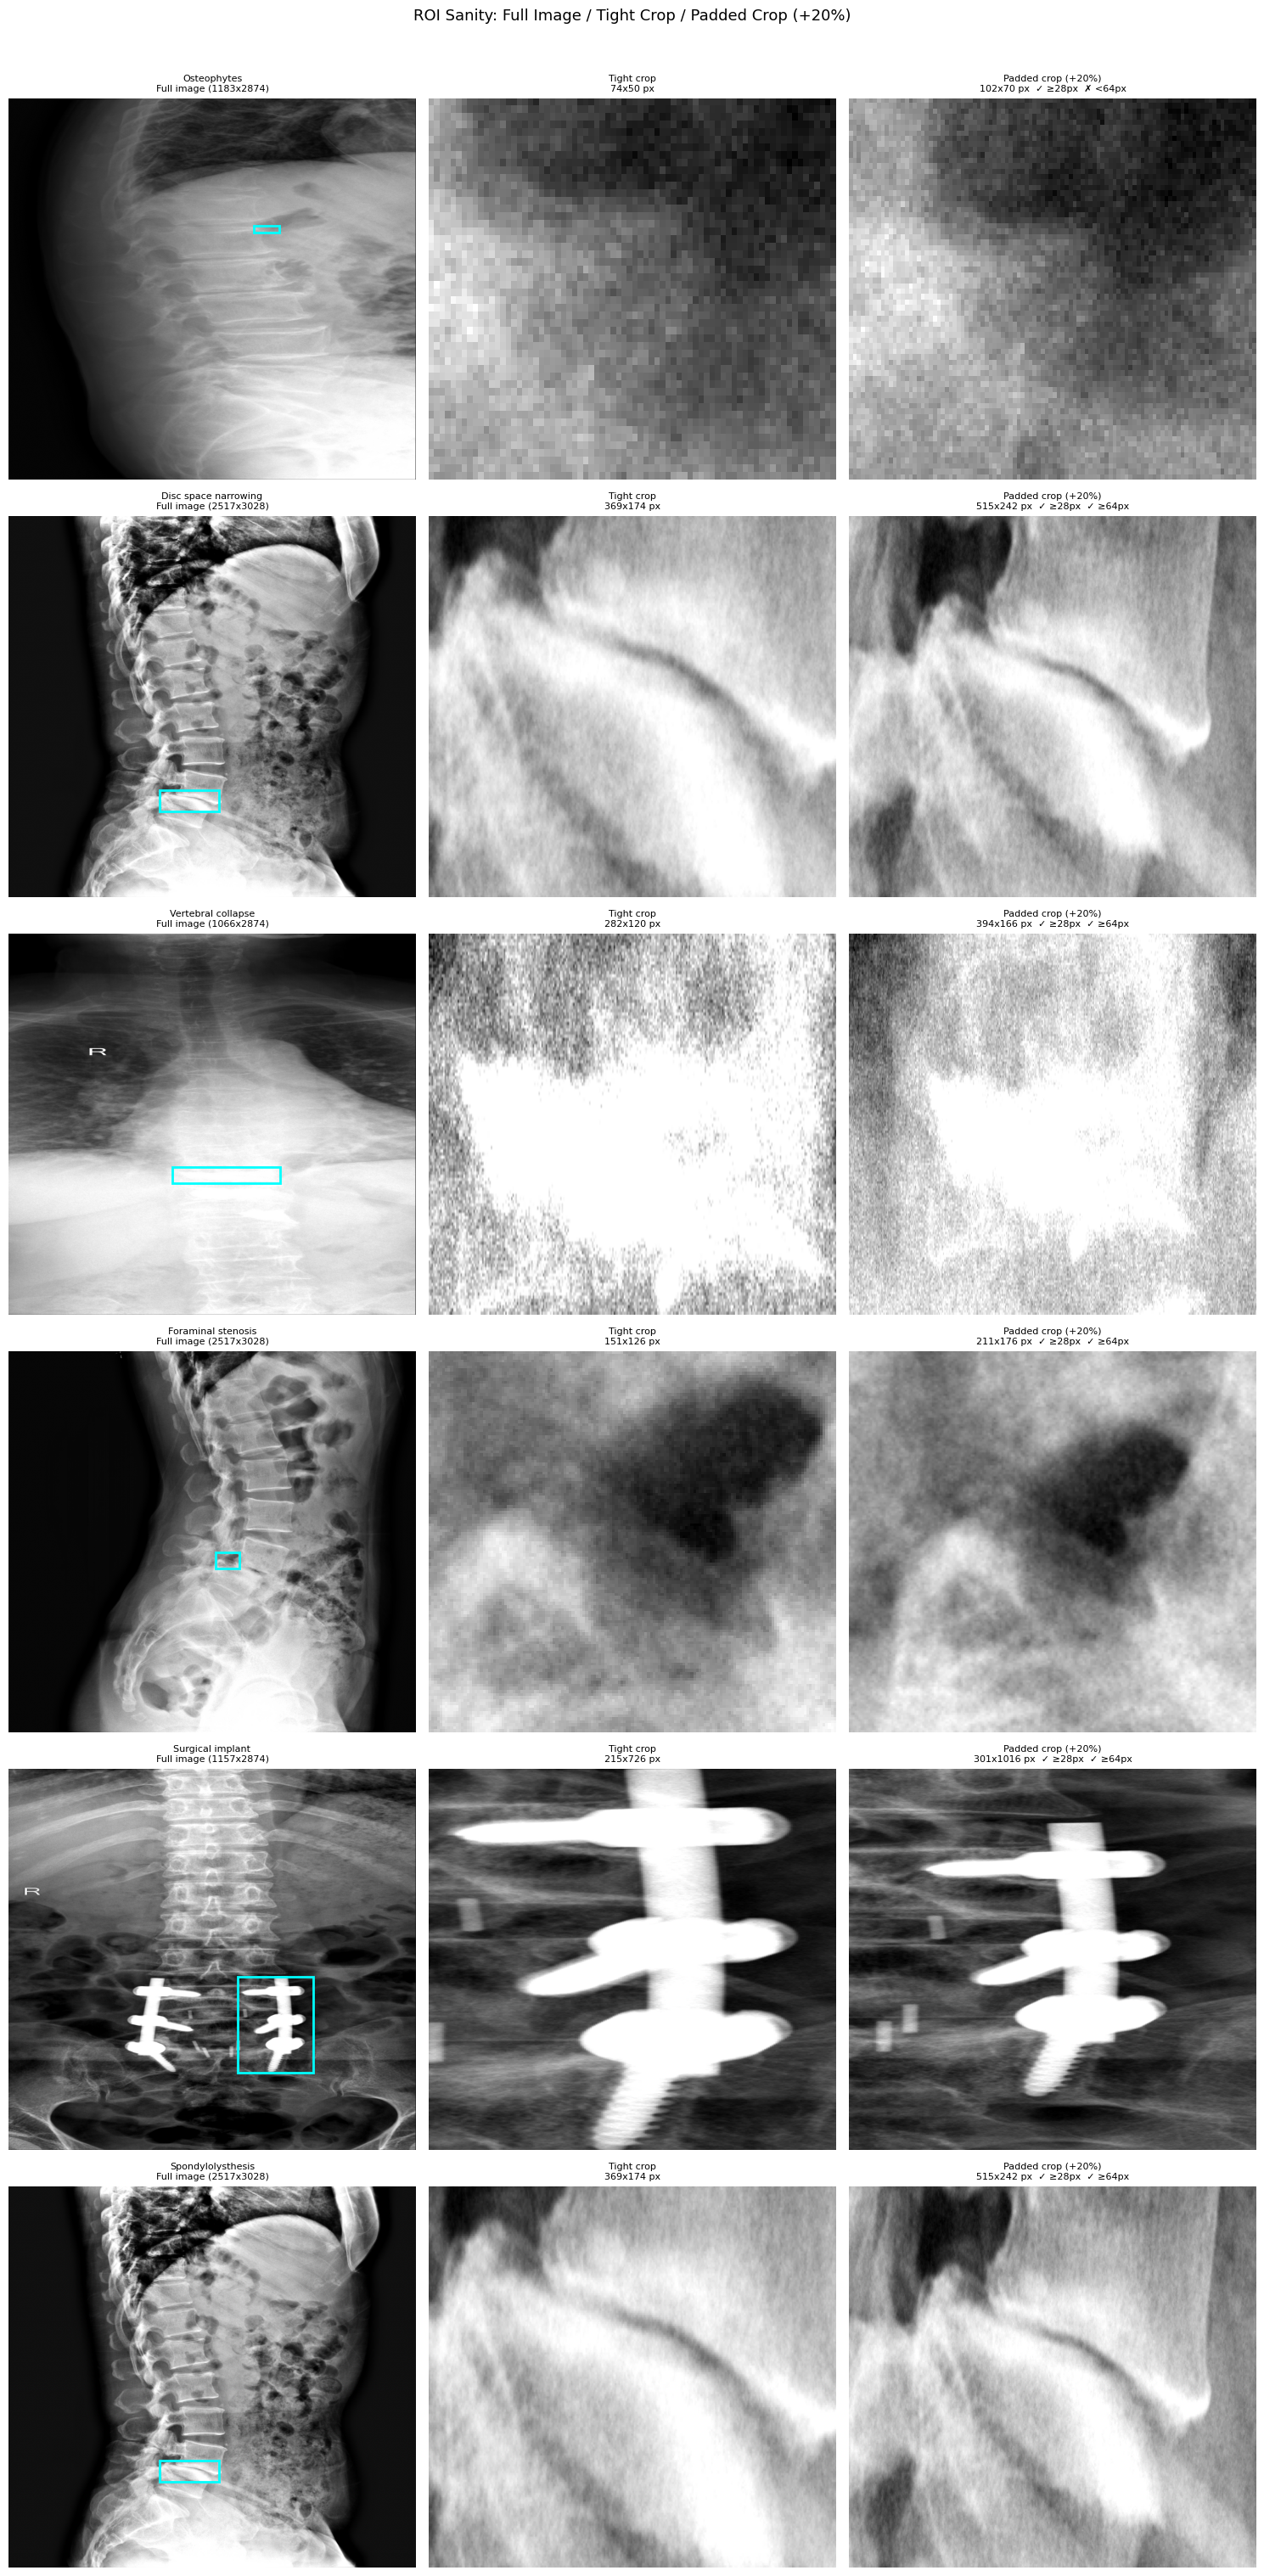

In [23]:
fig, axes = plt.subplots(len(roi_examples), 3, figsize=(15, len(roi_examples) * 5))
if len(roi_examples) == 1:
    axes = axes[np.newaxis, :]

for row_idx, ex in enumerate(roi_examples):
    arr = load_dicom_normalized(ex['image_id'])
    x1, y1, x2, y2 = ex['x1'], ex['y1'], ex['x2'], ex['y2']
    bw, bh = x2 - x1, y2 - y1

    # Col 0: full image with bbox overlay
    ax = axes[row_idx, 0]
    ax.imshow(arr, cmap='gray', aspect='auto')
    rect = patches.Rectangle((x1, y1), bw, bh,
                               linewidth=2, edgecolor='cyan', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"{ex['lesion_type']}\nFull image ({arr.shape[1]}x{arr.shape[0]})", fontsize=8)
    ax.axis('off')

    # Col 1: tight crop
    tight = crop_roi(arr, x1, y1, x2, y2, pad_frac=0.0)
    ax = axes[row_idx, 1]
    ax.imshow(tight, cmap='gray', aspect='auto')
    ax.set_title(f'Tight crop\n{tight.shape[1]}x{tight.shape[0]} px', fontsize=8)
    ax.axis('off')

    # Col 2: padded crop (20% padding)
    padded = crop_roi(arr, x1, y1, x2, y2, pad_frac=0.20)
    ax = axes[row_idx, 2]
    ax.imshow(padded, cmap='gray', aspect='auto')
    enough_28 = '✓ ≥28px' if tight.shape[0] >= 28 and tight.shape[1] >= 28 else '✗ <28px'
    enough_64 = '✓ ≥64px' if tight.shape[0] >= 64 and tight.shape[1] >= 64 else '✗ <64px'
    ax.set_title(f'Padded crop (+20%)\n{padded.shape[1]}x{padded.shape[0]} px  {enough_28}  {enough_64}',
                 fontsize=8)
    ax.axis('off')

plt.suptitle('ROI Sanity: Full Image / Tight Crop / Padded Crop (+20%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 7 — Data Quality Checks

Surface data quality issues before any downstream use.

In [24]:
quality_report = []

# Check 1: Images with no bbox entries (No finding rows count as intentional — flag separately)
all_annotated_ids = set(df_train['image_id'].unique())
train_image_id_from_files = set(f.replace('.dicom', '') for f in train_files)
missing_annotation = train_image_id_from_files - all_annotated_ids
quality_report.append({
    'Check': 'Images on disk with no annotation entry',
    'Count': len(missing_annotation),
    'Result': 'None detected' if len(missing_annotation) == 0 else f'{len(missing_annotation)} images'
})

# Check 2: Images in annotation but not on disk
missing_on_disk = all_annotated_ids - train_image_id_from_files
quality_report.append({
    'Check': 'Annotated image IDs missing from disk',
    'Count': len(missing_on_disk),
    'Result': 'None detected' if len(missing_on_disk) == 0 else f'{len(missing_on_disk)} IDs'
})

# Check 3: Invalid bbox coordinates (xmin >= xmax or ymin >= ymax)
df_b = df_train.dropna(subset=['xmin', 'ymin', 'xmax', 'ymax'])
invalid_x = (df_b['xmin'] >= df_b['xmax']).sum()
invalid_y = (df_b['ymin'] >= df_b['ymax']).sum()
quality_report.append({
    'Check': 'Invalid bbox: xmin >= xmax',
    'Count': int(invalid_x),
    'Result': 'None detected' if invalid_x == 0 else f'{invalid_x} rows'
})
quality_report.append({
    'Check': 'Invalid bbox: ymin >= ymax',
    'Count': int(invalid_y),
    'Result': 'None detected' if invalid_y == 0 else f'{invalid_y} rows'
})

# Check 4: Zero-area boxes
zero_w = (df_bbox['width']  <= 0).sum()
zero_h = (df_bbox['height'] <= 0).sum()
quality_report.append({
    'Check': 'Zero-area bbox (width or height ≤ 0)',
    'Count': int(zero_w + zero_h),
    'Result': 'None detected' if (zero_w + zero_h) == 0 else f'{zero_w + zero_h} rows'
})

# Check 5: Out-of-bounds boxes (need image dimensions)
# Use sampled dims from Section 3
oob = df_sample_bbox[
    (df_sample_bbox['xmin'] < 0) | (df_sample_bbox['ymin'] < 0) |
    (df_sample_bbox['xmax'] > df_sample_bbox['img_cols']) |
    (df_sample_bbox['ymax'] > df_sample_bbox['img_rows'])
]
quality_report.append({
    'Check': f'Out-of-bounds bbox coords (sample n={len(df_sample_bbox)})',
    'Count': len(oob),
    'Result': 'None detected' if len(oob) == 0 else f'{len(oob)} rows'
})

# Check 6: Duplicate image IDs in annotation file
# An image can legitimately have multiple rows (multiple bboxes, multiple rads)
# Flag if same (image_id, rad_id, lesion_type, xmin, ymin) appears twice
dup_cols = ['image_id', 'rad_id', 'lesion_type', 'xmin', 'ymin']
dupes = df_train[df_train.duplicated(subset=dup_cols, keep=False) & df_train['xmin'].notna()]
quality_report.append({
    'Check': 'Duplicate annotation rows (same image/rad/label/coords)',
    'Count': len(dupes),
    'Result': 'None detected' if len(dupes) == 0 else f'{len(dupes)} rows'
})

# Check 7: Split leakage — image IDs in both train and test
train_ids_set = set(df_train['image_id'].unique())
test_ids_set  = set(df_test['image_id'].unique())
overlap = train_ids_set & test_ids_set
quality_report.append({
    'Check': 'Split leakage (image_id in both train and test)',
    'Count': len(overlap),
    'Result': 'None detected' if len(overlap) == 0 else f'{len(overlap)} image IDs'
})

# Print summary
df_quality = pd.DataFrame(quality_report)
print('=== Data Quality Check Summary ===')
display(df_quality)

=== Data Quality Check Summary ===


,Check,Count,Result
0,Images on disk with no annotation entry,0,None detected
1,Annotated image IDs missing from disk,0,None detected
2,Invalid bbox: xmin >= xmax,0,None detected
3,Invalid bbox: ymin >= ymax,0,None detected
4,Zero-area bbox (width or height ≤ 0),0,None detected
5,Out-of-bounds bbox coords (sample n=703),1,1 rows
6,Duplicate annotation rows (same image/rad/labe...,226,226 rows
7,Split leakage (image_id in both train and test),0,None detected


---
## Section 8 — Initial Observations

Dataset characteristics relevant to binary classification planning (observations only — no final decision in this slice).

---

### Class Imbalance

**Yes — significant.** Osteophytes is the dominant class at ~64% of all annotations, more than 12× the frequency of the rarest individual pathologies (Spondylolysthesis, Vertebral collapse). "No finding" accounts for ~22% of annotation rows (but these are normal images with no bbox, not a balanced negative class).  
Any binary task constructed from this data will require explicit class weighting or resampling.

---

### ROI Size — Feasibility for Classification Crops

**Yes — ROIs are large enough.** Bounding boxes are measured in hundreds of pixels (median width ~170 px, median height ~130 px against images that are typically 1000–3000 px tall). Even tight crops are comfortably above the 28×28 and 64×64 thresholds. A 224×224 crop target (standard for CNN fine-tuning) is feasible with padding for most boxes. Very small outlier boxes exist (tail of the distribution) and should be filtered by a minimum area threshold at preprocessing time.

---

### Noisy or Suspicious Labels

- **"Other lesions"** (~2.3% of annotations): a catch-all class with no defined meaning — not suitable as a binary target without expert review.
- **Multi-annotator disagreement**: three radiologists annotate the same images (rad1, rad2, rad3). Agreement rate is not computed here but is a known source of label noise in VinDr datasets.
- **Overlapping bboxes on the same image**: an image can carry multiple lesion types simultaneously (multi-label), which complicates binary-task framing unless a clear label hierarchy is applied.

---

### Image Preprocessing Concerns

- **DICOM format, JPEG 2000 compressed.** Standard DICOM windowing (center/width) may be needed for optimal display but is not applied here. `pydicom` pixel_array values are raw stored values (uint16, 12–14 bit depth based on samples).
- **High resolution variability.** Images range from ~1000 to >3000 px in both dimensions; aggressive downsampling to 28×28 will lose all ROI detail — at minimum 224×224 crops should be used, or the CNN backbone adapted.
- **Portrait orientation.** All sampled images have aspect ratio > 1 (taller than wide), typical of spine X-rays.
- **No pixel_array inversion check performed** — some DICOM files use MONOCHROME1 (inverted) photometric interpretation; this should be checked and corrected during preprocessing.

---

### Likely Binary-Task Candidates (observations only)

Based purely on label distribution:

| Candidate | Positive class | Approximate positive images (train, rad1) | Notes |
|---|---|---|---|
| A | Osteophytes vs. No finding | ~3,000+ vs. ~1,400 | Most data; still imbalanced |
| B | Pathology (any) vs. No finding | ~5,700 vs. ~1,400 | Broad positive definition |
| C | Osteophytes vs. Disc space narrowing | ~3,000 vs. ~300 | Highly imbalanced; fine-grained |
| D | Osteophytes vs. all other pathologies | ~3,000 vs. ~2,700 | Most balanced; complex negative class |

No final decision is made here. The binary task, label encoding strategy, and multi-annotator handling will be determined in Slice Q11.

---

### Other Observations

- **Data quality is high**: no split leakage, no duplicate annotations, no invalid/zero-area bboxes found.
- **Multi-rad annotation structure is an asset**: consensus or majority-vote labels can be constructed if label noise from single-rad annotations is a concern.
- **No val split present**: only train and test. A validation split will need to be carved from train for model development.
- **Dataset is large enough**: 8,389 train images is a reasonable scale for ROI-level binary classification experiments.